In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('shopping.csv',index_col='Customer ID')

In [34]:
df_for_eda = df.copy()

In [8]:
df.head(2)

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
Customer ID,,,,,,,,,,,,,,,
1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Yes,14,Venmo,Fortnightly
2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Yes,2,Cash,Fortnightly


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3900 entries, 1 to 3900
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     3900 non-null   int64  
 1   Gender                  3900 non-null   object 
 2   Item Purchased          3900 non-null   object 
 3   Category                3900 non-null   object 
 4   Purchase Amount (USD)   3900 non-null   int64  
 5   Location                3900 non-null   object 
 6   Size                    3900 non-null   object 
 7   Color                   3900 non-null   object 
 8   Season                  3900 non-null   object 
 9   Review Rating           3900 non-null   float64
 10  Subscription Status     3900 non-null   object 
 11  Discount Applied        3900 non-null   object 
 12  Previous Purchases      3900 non-null   int64  
 13  Payment Method          3900 non-null   object 
 14  Frequency of Purchases  3900 non-null   objec

In [10]:
df.describe()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000
mean,44.068462,59.764359,3.749949,25.351538
std,15.207589,23.685392,0.716223,14.447125
min,18.000000,20.000000,2.500000,1.000000
25%,31.000000,39.000000,3.100000,13.000000
50%,44.000000,60.000000,3.700000,25.000000
75%,57.000000,81.000000,4.400000,38.000000
max,70.000000,100.000000,5.000000,50.000000


In [11]:
df.isnull().sum()

Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Discount Applied          0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

C:\Users\Rajat jha\AppData\Local\Temp\ipykernel_872\4082091002.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Category', y='Purchase Amount (USD)', ax=axes[0, 1], palette='magma')
C:\Users\Rajat jha\AppData\Local\Temp\ipykernel_872\4082091002.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=season_sales, x='Season', y='Purchase Amount (USD)', ax=axes[1, 1], palette='viridis')


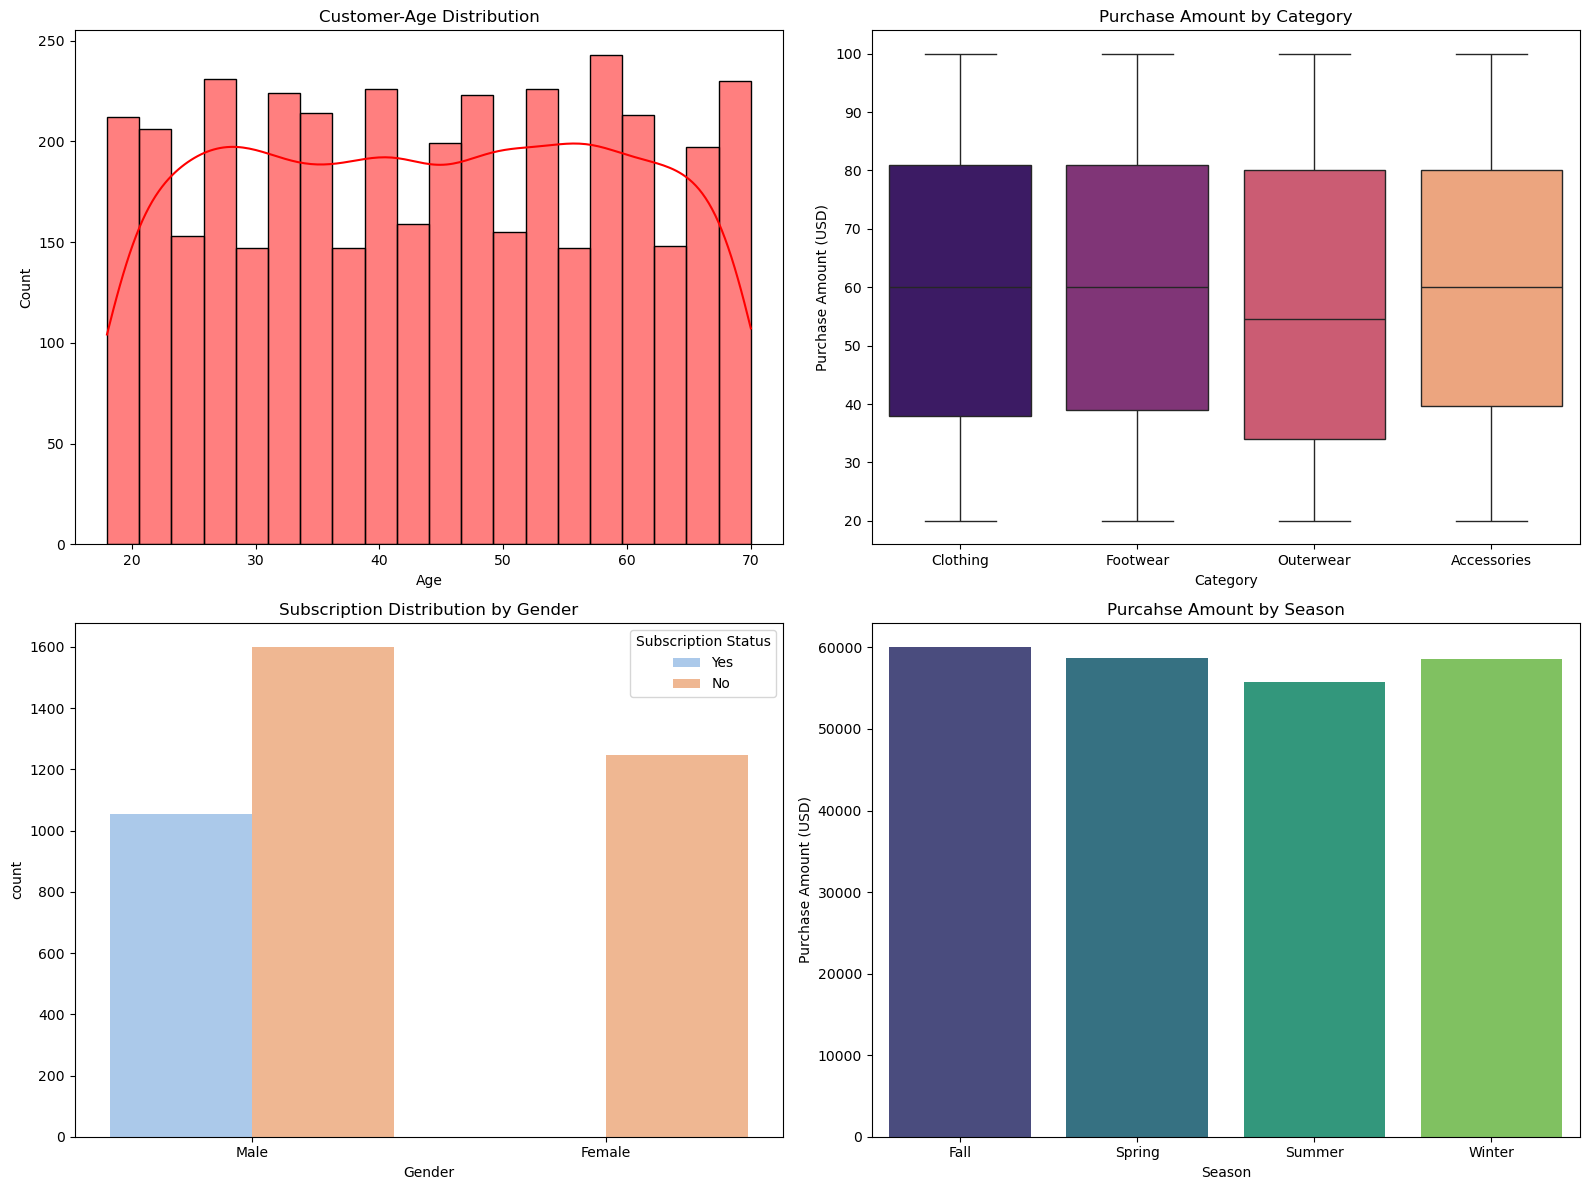

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.histplot(df['Age'], bins=20, kde=True, ax=axes[0, 0], color='red')
axes[0, 0].set_title('Customer-Age Distribution')

sns.boxplot(data=df, x='Category', y='Purchase Amount (USD)', ax=axes[0, 1], palette='magma')
axes[0, 1].set_title('Purchase Amount by Category')

sns.countplot(data=df, x='Gender', hue='Subscription Status', ax=axes[1, 0], palette='pastel')
axes[1, 0].set_title('Subscription Distribution by Gender')

season_sales = df.groupby('Season')['Purchase Amount (USD)'].sum().reset_index()
sns.barplot(data=season_sales, x='Season', y='Purchase Amount (USD)', ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('Purcahse Amount by Season')

plt.tight_layout()
plt.show()

In [13]:
df.duplicated().sum()

0

FEATURE ENGINEERING

In [16]:
categorical_cols = [col for col in df.columns if df[col].dtype == "O"]
numerical_cols = [col for col in df.columns if df[col].dtype != "O"]

In [17]:
binary_cols = ["Gender", "Subscription Status", "Discount Applied"]
for col in binary_cols:
    df[col] = df[col].map({'No':0,'Yes':1,'Male':0,'Female':1})

In [18]:
size_map = {
    'S':0,
    'M':1,
    'L':2,
    'XL':3
}
df['Size'] = df['Size'].map(size_map)

In [19]:
freq_map = { "Weekly": 1, "Bi-Weekly": 2,
            "Fortnightly": 3, "Monthly": 4,
            "Quarterly": 5, "Every 3 Months": 6,
            "Annually": 7
           }
df["Frequency of Purchases"] = df["Frequency of Purchases"].map(freq_map)

In [20]:
freq_encode_cols = ["Item Purchased", "Color", "Location"] 
for col in freq_encode_cols: 
    freq_map = df[col].value_counts(normalize=True)
    df[col] = df[col].map(freq_map)

In [21]:
one_hot_cols = ["Category", "Season", "Payment Method"]
df = pd.get_dummies(df, columns=one_hot_cols, drop_first=True,dtype=int)

SCALING + PCA +K-MEANS CLUSTERING

In [22]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [23]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [24]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [25]:
df_pca = pd.DataFrame(data = X_pca,columns=['PC1','PC2'])

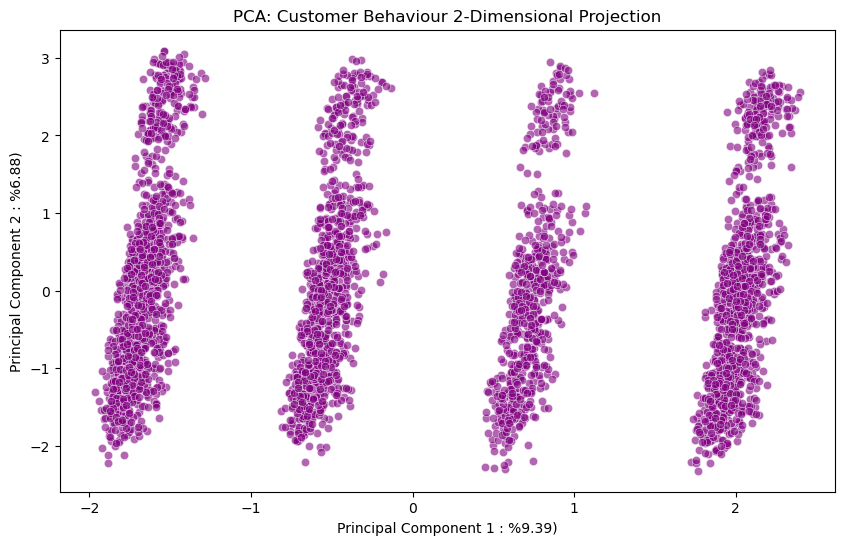

In [26]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', data=df_pca, alpha=0.6, color='purple')
plt.xlabel(f'Principal Component 1 : %{pca.explained_variance_ratio_[0]*100:.2f})')
plt.ylabel(f'Principal Component 2 : %{pca.explained_variance_ratio_[1]*100:.2f})')
plt.title('PCA: Customer Behaviour 2-Dimensional Projection')
plt.show()

In [28]:
from sklearn.cluster import KMeans

In [29]:
wcss_pca = []

In [30]:
import warnings
warnings.filterwarnings('ignore')
for i in range(1,11):
    kmeans = KMeans(n_clusters=i,init = 'k-means++',random_state=42)
    kmeans.fit(X_pca)
    wcss_pca.append(kmeans.inertia_)

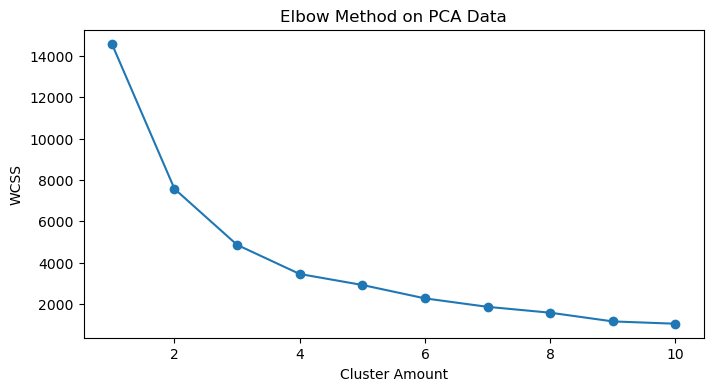

In [31]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss_pca, marker='o')
plt.title('Elbow Method on PCA Data')
plt.xlabel('Cluster Amount')
plt.ylabel('WCSS')
plt.show()

In [32]:
n_clusters = 3
kmeans_pca = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42)
cluster_labels = kmeans_pca.fit_predict(X_pca)

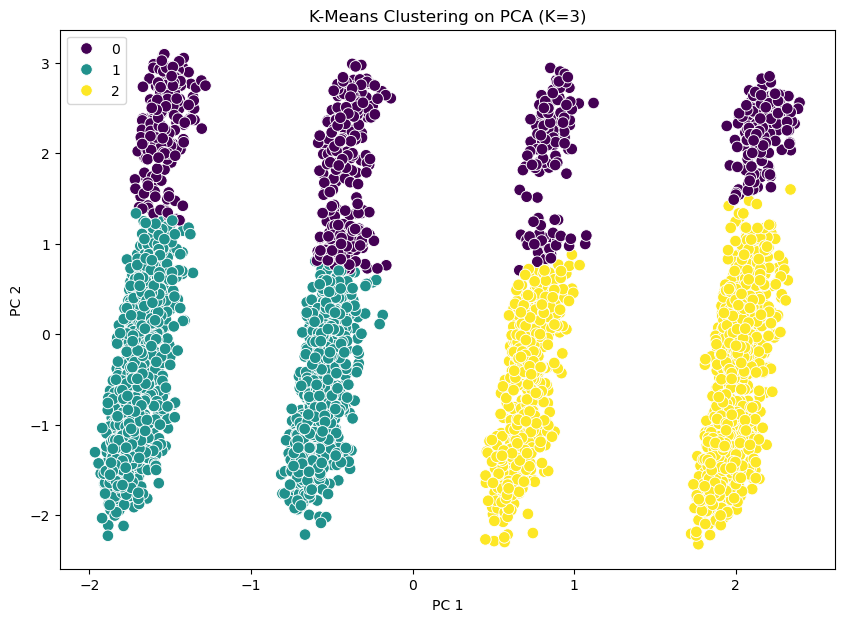

In [33]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=cluster_labels, palette='viridis', s=70)


plt.title(f'K-Means Clustering on PCA (K={n_clusters})')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.show()

In [35]:
df_for_eda['Cluster'] = cluster_labels

In [36]:
print(df_for_eda.groupby('Cluster')[['Age', 'Purchase Amount (USD)', 'Previous Purchases']].mean())

               Age  Purchase Amount (USD)  Previous Purchases
Cluster                                                      
0        44.388889              60.459350           24.716802
1        43.808932              60.245902           25.284341
2        44.228284              58.784637           25.773151


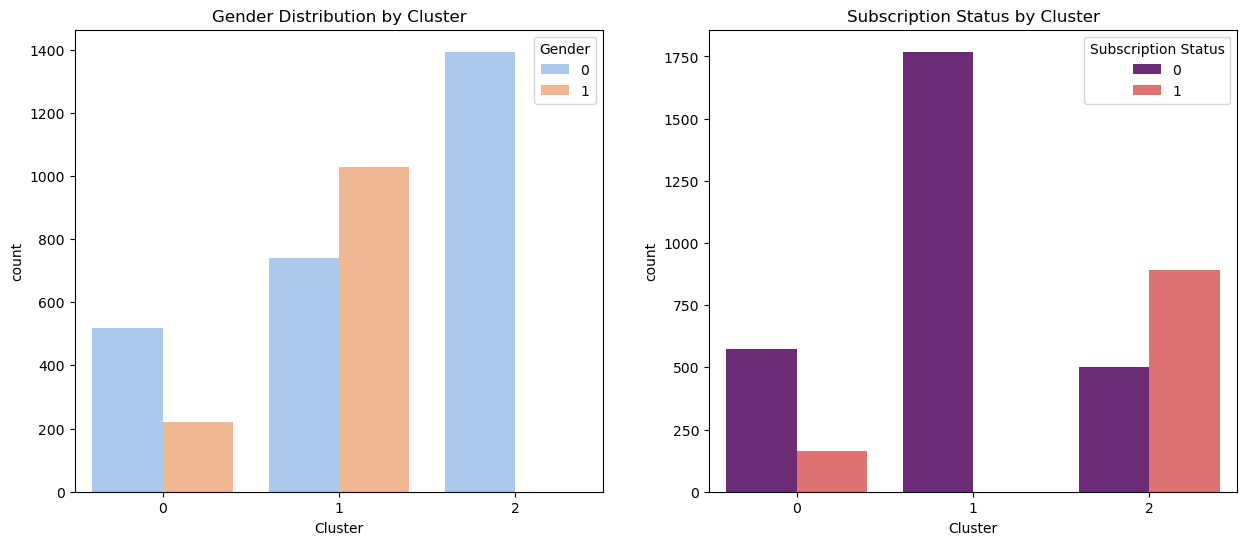

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.countplot(data=df_for_eda, x='Cluster', hue='Gender', ax=axes[0], palette='pastel')
axes[0].set_title('Gender Distribution by Cluster')

sns.countplot(data=df_for_eda, x='Cluster', hue='Subscription Status', ax=axes[1], palette='magma')
axes[1].set_title('Subscription Status by Cluster')
plt.show()

In [40]:
df_for_eda.head()

,Age,Gender,Item Purchased,Purchase Amount (USD),Location,Size,Color,Review Rating,Subscription Status,Discount Applied,...,Category_Outerwear,Season_Spring,Season_Summer,Season_Winter,Payment Method_Cash,Payment Method_Credit Card,Payment Method_Debit Card,Payment Method_PayPal,Payment Method_Venmo,Cluster
Customer ID,,,,,,,,,,,,,,,,,,,,,
1,55,0,0.043846,53,0.020256,2,0.040769,3.1,1,1,...,0,0,0,1,0,0,0,0,1,2
2,19,0,0.042051,64,0.019744,2,0.040513,3.1,1,1,...,0,0,0,1,1,0,0,0,0,2
3,50,0,0.031795,73,0.018462,0,0.040513,3.1,1,1,...,0,1,0,0,0,1,0,0,0,2
4,21,0,0.041026,90,0.016154,1,0.040513,3.5,1,1,...,0,1,0,0,0,0,0,1,0,0
5,45,0,0.043846,49,0.018974,1,0.037179,2.7,1,1,...,0,1,0,0,0,0,0,1,0,2


In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_for_eda, x='Cluster', hue='Category', palette='Set2')
plt.title('Product Category Preferences by Cluster')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [42]:
pca_cols = [col for col in df.columns if col != 'Cluster']

loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=pca_cols)

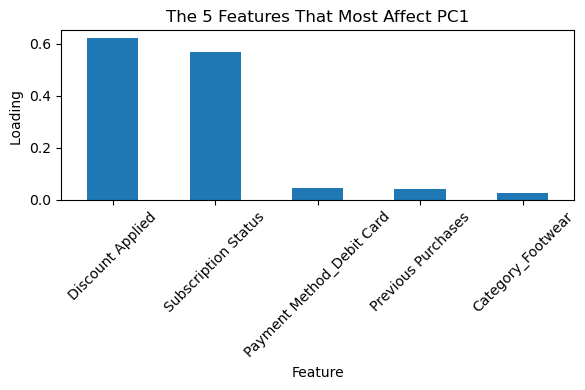

In [43]:
top5_pc1 = loadings['PC1'].sort_values(ascending=False).head(5)

plt.figure(figsize=(6,4))
top5_pc1.plot(kind='bar')
plt.title("The 5 Features That Most Affect PC1")
plt.ylabel("Loading ")
plt.xlabel("Feature")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

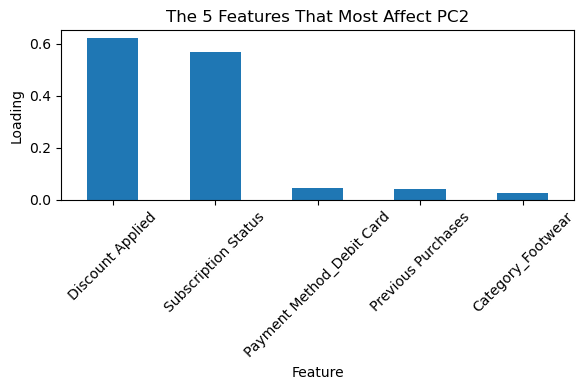

In [44]:
top5_pc2 = loadings['PC2'].sort_values(ascending=False).head(5)

plt.figure(figsize=(6,4))
top5_pc1.plot(kind='bar')
plt.title("The 5 Features That Most Affect PC2")
plt.ylabel("Loading")
plt.xlabel("Feature")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [45]:
df['Cluster'] = cluster_labels